# Section 5.1: Synthetic Gaussian Data-Generating Process

Reproduces **Figure 1** of the paper. We construct a fully controlled
multivariate Gaussian DGP with $T = 4$ output components and $p = 4$
input features, where each feature plays a *known* role:

- $x_1$ drives the **mean** only, i.e., should be invisible to the uncertainty hierarchy at every level.
- $x_2$ drives the **marginal variance**, with an effect that grows with $t$.
- $x_3$ drives **variance and correlation** simultaneously.
- $x_4$ drives **correlation only**, leaving every marginal invariant.

Because the entropy and conditional entropy of a multivariate Gaussian have closed forms (Sec. 4.2.1), we can compute every level analytically and verify that:

- **Proposition 1** (chain-rule linkage):
  $\phi^{\mathrm{joint}} = \sum_t \phi^{(t \mid <t)}$.
- **Proposition 2** (cross-component decomposition):
  $\phi^{\mathrm{TC}} = \sum_t \phi^{(t)} - \phi^{\mathrm{joint}}$.
- $x_4$ is the blind-spot example: it is invisible to Level 1 yet dominant at the cross-component term.

All figures are written to `plots/5_1/` and intermediate Shapley caches to `results/5_1/`.

> **Note.** This notebook is intended to be executed top-to-bottom in a single run (e.g. *Run All*). The global NumPy RNG is seeded once at the top, so re-running individual cells out of order can change the background sample and shift Shapley values by Monte-Carlo noise.


In [1]:
import sys, os, time
sys.path.insert(0, os.path.join(os.path.abspath(""), ".."))
start_time = time.time()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon, Rectangle
from matplotlib import gridspec

# Import necessary classes of entropy_shapley 
from entropy_shapley import MarginalTabularSampler, GaussianImputer, HierarchyGame

# Output directory: figures saved at the version_2/plots level
plot_dir = '../plots/5_1'
res_dir = '../results/5_1'
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(res_dir, exist_ok=True)

# Reproducibility seed
seed = 123
np.random.seed(seed)


## 1) Data-Generating Process

| Feature | Symbol | Role |
|---------|--------|------|
| $x_1$ | `mean` | Drives **mean** $\mu_t(\mathbf{x}) = x_1 \sin(2\pi t / T)$ |
| $x_2$ | `var` | Drives **marginal variance** (ascending effect over components)|
| $x_3$ | `var+corr` | Drives **variance** and **correlation** simultaneously (independent of $t$) |
| $x_4$ | `corr` | Drives **correlation** $\rho(\mathbf{x}) = \tanh(\delta_0 x_4 + \delta_1 x_3)$ (independent of $t$) |


In [2]:
# Global parameters
T = 4       # forecast components
p = 4       # features
N = 100    # samples for visualisation
N_BACKGROUND = 10_000  # background samples for Shapley value estimation

# Data generation parameters
beta  = 1.0             # effect of x1 on mean
gamma = [0.5, 0.8]      # effect of x2 and x3 on variance
delta = [-0.6, 1.25]    # effect of x3 and x4 on correlation

# Mu vector (only depends on x1)
def mu(x: np.ndarray) -> np.ndarray:
    t = np.arange(1, T + 1)
    return beta * x[..., 0:1] * np.sin(2 * np.pi * t / T)

# Sigma matrix (depends on x2, x3, x4)
def sigma(x: np.ndarray) -> np.ndarray:
    t        = np.arange(1, T + 1)

    # Variance depends on x2 and x3
    # D_tt = gamma[0] * x2 + gamma[1] * x3 * t
    s2       = np.exp(gamma[0] * x[..., 1:2] * t + gamma[1] * x[..., 2:3])
    D        = np.sqrt(s2)[..., None] * np.eye(T)

    # Correlation depends on x3 and x4
    # r = tanh(delta[0] * x3 + delta[1] * x4) to ensure |r| < 1
    # R_ij = sign(r) * |r|^(|i-j|^1.5) to ensure positive definiteness
    r        = np.tanh(delta[0] * x[..., 2:3] + delta[1] * x[..., 3:4])
    int_diff = np.abs(np.arange(T)[:, None] - np.arange(T)[None, :])
    R        = np.sign(r[..., None]) ** int_diff * np.abs(r[..., None]) ** (int_diff ** 1.5)
    
    return D @ R @ D

# Define DGP as the model
def GaussianModel(X):
    return sigma(X)   # (n, T, T)

## 2) Two Forecast Instances

We pick two instances with contrasting profiles:
- $\mathbf{x}_a = (1, 1, 1, 1.75)$: very high correlation ($\rho > 0$), moderate variance **(shown in the paper)**
- $\mathbf{x}_b = (-2, -1, 0.1, -0.2)$: negative mean, low correlation

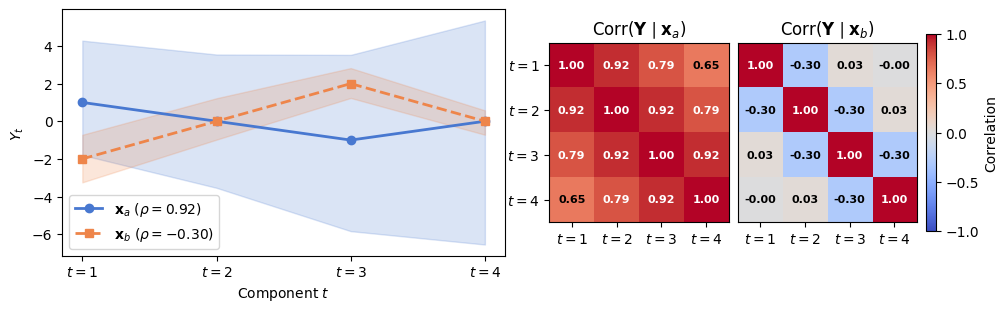

In [3]:
# Define two instances for visualisation
x_a = np.array([1, 1, 1, 1.75])
x_b = np.array([-2, -1, 0.1, -0.2])

# Compute Mu and Sigma for both instances
Mu_a, Mu_b = mu(x_a), mu(x_b)
Sigma_a, Sigma_b = sigma(x_a), sigma(x_b)

# Sample some trajectories for visualisation
Y_samp_a     = np.random.multivariate_normal(Mu_a, Sigma_a, N)
Y_samp_b     = np.random.multivariate_normal(Mu_b, Sigma_b, N)
q05_a, q95_a = np.quantile(Y_samp_a, [0.05, 0.95], axis=0)
q05_b, q95_b = np.quantile(Y_samp_b, [0.05, 0.95], axis=0)

# Compute correlation matrices and overall correlation strength for both instances
cov_to_corr = lambda S: S / np.sqrt(np.outer(np.diag(S), np.diag(S)))
R_a = cov_to_corr(Sigma_a)
R_b = cov_to_corr(Sigma_b)
rho_a = np.tanh(delta[0] * x_a[2] + delta[1] * x_a[3])
rho_b = np.tanh(delta[0] * x_b[2] + delta[1] * x_b[3])

# Define labels for plotting
t      = np.arange(1, T + 1)
labels = [f'$t={i}$' for i in t]

# Define colors for plotting
cols = sns.color_palette("muted", n_colors=2).as_hex()

# Create figure with nested grids
fig = plt.figure(figsize=(12, 3.2))
outer = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.1)
right = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.05)

axes = [fig.add_subplot(outer[0]), fig.add_subplot(right[0]), fig.add_subplot(right[1])]
ax = axes[0]
ax.fill_between(t, q05_a, q95_a, alpha=0.2, color=cols[0])
ax.plot(t, Mu_a, 'o-', color=cols[0], linewidth=2,
        label=rf'$\mathbf{{x}}_a$ ($\rho={rho_a:.2f}$)')
ax.fill_between(t, q05_b, q95_b, alpha=0.2, color=cols[1])
ax.plot(t, Mu_b, 's--', color=cols[1], linewidth=2,
        label=rf'$\mathbf{{x}}_b$ ($\rho={rho_b:.2f}$)')
ax.set(xticks=t, xticklabels=labels, xlabel='Component $t$', ylabel='$Y_t$',
       title=None)
ax.legend()

def plot_corr(ax, R, title):
    im = ax.imshow(R, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set(title=title, xticks=range(T), yticks=range(T),
           xticklabels=labels, yticklabels=labels)
    for i in range(T):
        for j in range(T):
            color = 'white' if abs(R[i, j]) > 0.7 else 'black'
            ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')
    return im

plot_corr(axes[1], R_a, r'$\mathrm{Corr}(\mathbf{Y} \mid \mathbf{x}_a)$')
im = plot_corr(axes[2], R_b, r'$\mathrm{Corr}(\mathbf{Y} \mid \mathbf{x}_b)$')
axes[2].set_yticks([])
fig.colorbar(im, ax=axes[1:], shrink=0.8, label='Correlation', pad=0.02)

# Save figure and show
fig.savefig(f'{plot_dir}/predictive_distributions.pdf', bbox_inches='tight')
plt.show()


## 3) Entropy-Shapley Hierarchy

We compute Shapley values for **three entropy levels** of the multivariate Gaussian:

| Level | Quantity | Intuition |
|-------|----------|-----------|
| **L1** | $H(Y_t \mid \mathbf{x})$ | Marginal forecast uncertainty at horizon $t$ |
| **L2** | $H(Y_t \mid Y_{<t}, \mathbf{x})$ | Conditional uncertainty given past observations |
| **L3** | $H(\mathbf{Y} \mid \mathbf{x})$ | Joint uncertainty of the full trajectory |

The **cross term** $\phi^{\text{cross}}_j = \sum_t \phi^{(t)}_j - \phi^{\text{joint}}_j$
captures how much feature $j$ reduces uncertainty through *temporal correlation*.

We explain instance $\mathbf{x}_a$ using `GaussianHierarchyImputer` with a marginal
background distribution ($N=10{,}000$ background samples).

In [4]:
x          = x_a
background = np.random.randn(N_BACKGROUND, p)

# Define imputer and game for Shapley value estimation
sampler = MarginalTabularSampler(background, sample_size=N_BACKGROUND)
imputer = GaussianImputer(GaussianModel, sampler, x, T)

# Run calculation using all subsets S
game    = HierarchyGame(imputer).precompute()

# Extract Shapley values
phi_L1      = np.stack([game.game_L1(t).exact_values('SII', order=1).values[1:] for t in range(T)])
phi_L2      = np.stack([game.game_L2(t).exact_values('SII', order=1).values[1:] for t in range(T)])
phi_L3      = game.game_L3().exact_values('SII', order=1).values[1:]
phi_cross_t = phi_L1 - phi_L2
phi_cross   = phi_L1.sum(axis=0) - phi_L3

# Store results in a dictionary
results = dict(phi_L1=phi_L1, phi_L2=phi_L2, phi_L3=phi_L3,
               phi_cross_t=phi_cross_t, phi_cross=phi_cross,
               x_a=x_a, x_b=x_b)

# Save results
np.savez(f'{res_dir}/shapley_values.npz', **results)

100%|██████████| 1/1 [00:00<00:00,  9.04it/s]


### Verification of Propositions 1 and 2

Sanity checks on the computed Shapley values:

- **Prop. 1 (chain rule):** $\varphi^{\text{joint}}_j = \sum_t \varphi^{(t|<t)}_j$.
- **Prop. 2 (cross = TC game):** $\sum_j \varphi^{\text{cross}}_j = \mathrm{TC}(Y\mid x) - \mathrm{TC}(Y\mid X)$,
  where the right-hand side is computed analytically from the Gaussian covariance matrices over the background distribution.


In [5]:
# --- Prop. 1 (chain rule): phi_joint = sum_t phi_L2_t -----------------
prop1_residual = phi_L3 - phi_L2.sum(axis=0)
print(f"Prop. 1 (chain rule):  max |residual|     = {np.max(np.abs(prop1_residual)):.2e}")

# --- Prop. 2 (cross = TC game): sum_j phi_cross_j = TC(Y|x) - TC(Y|X) -
def total_corr_gauss(S):
    """Total correlation of multivariate Gaussian: 0.5 * (sum log diag - log det)."""
    diag_log  = np.log(np.diagonal(S, axis1=-2, axis2=-1)).sum(axis=-1)
    _, logdet = np.linalg.slogdet(S)
    return 0.5 * (diag_log - logdet)

TC_local  = total_corr_gauss(sigma(x))
TC_global = total_corr_gauss(sigma(background)).mean()
lhs, rhs  = phi_cross.sum(), TC_local - TC_global
print(f"Prop. 2 (cross = TC):  sum_j phi_cross_j   = {lhs: .6f}")
print(f"                       TC(Y|x) - TC(Y|X)   = {rhs: .6f}")
print(f"                       residual            = {lhs - rhs:.2e}")

# Hard assertions — these must hold for the paper claims to stand
assert np.max(np.abs(prop1_residual)) < 1e-8, "Prop. 1 (chain rule) violated"
assert abs(lhs - rhs) < 1e-3, "Prop. 2 (cross = TC) violated within MC tolerance"

# --- Qualitative DGP pattern: each feature carries only the role it was given ---
# x_1 enters only through the mean, so Sigma (and every entropy level) must ignore it.
# x_4 drives correlation only, so it is invisible at L1 but active at L2 / cross.
print(f"x_1 (mean only):       max |phi_L1[:,0]|   = {np.max(np.abs(phi_L1[:, 0])):.2e}")
print(f"                       max |phi_L2[:,0]|   = {np.max(np.abs(phi_L2[:, 0])):.2e}")
print(f"                       |phi_L3[0]|         = {abs(phi_L3[0]):.2e}")
print(f"x_4 (corr only):       max |phi_L1[:,3]|   = {np.max(np.abs(phi_L1[:, 3])):.2e}")
print(f"                       sum_t phi_L2[t,3]   = {phi_L2[:, 3].sum(): .6f}")
print(f"                       phi_cross[3]        = {phi_cross[3]: .6f}")


Prop. 1 (chain rule):  max |residual|     = 2.78e-13
Prop. 2 (cross = TC):  sum_j phi_cross_j   =  1.020070
                       TC(Y|x) - TC(Y|X)   =  1.020070
                       residual            = -3.51e-13
x_1 (mean only):       max |phi_L1[:,0]|   = 1.11e-16
                       max |phi_L2[:,0]|   = 1.11e-16
                       |phi_L3[0]|         = 2.22e-16
x_4 (corr only):       max |phi_L1[:,3]|   = 1.11e-16
                       sum_t phi_L2[t,3]   = -1.885800
                       phi_cross[3]        =  1.885800


## 4) Create Visualization

The figure shows all three Shapley levels side by side.
Ribbons connect individual-horizon bars (Level 1/2) to their stacked aggregate,
making the decomposition $\sum_t \phi^{(t)} = \phi^{\text{joint}} + \phi^{\text{cross}}$ visual.

**Expected pattern** (by DGP design):
- $x_1$ (mean): not visible, since it only affects the mean and not the $\Sigma$
- $x_2$ (var): increasing mass at L1, zero at L2.
- $x_3$ (var+corr): appears at both levels.
- $x_4$ (corr only): zero at L1, positive at L2 — correlation shrinks conditional entropy.

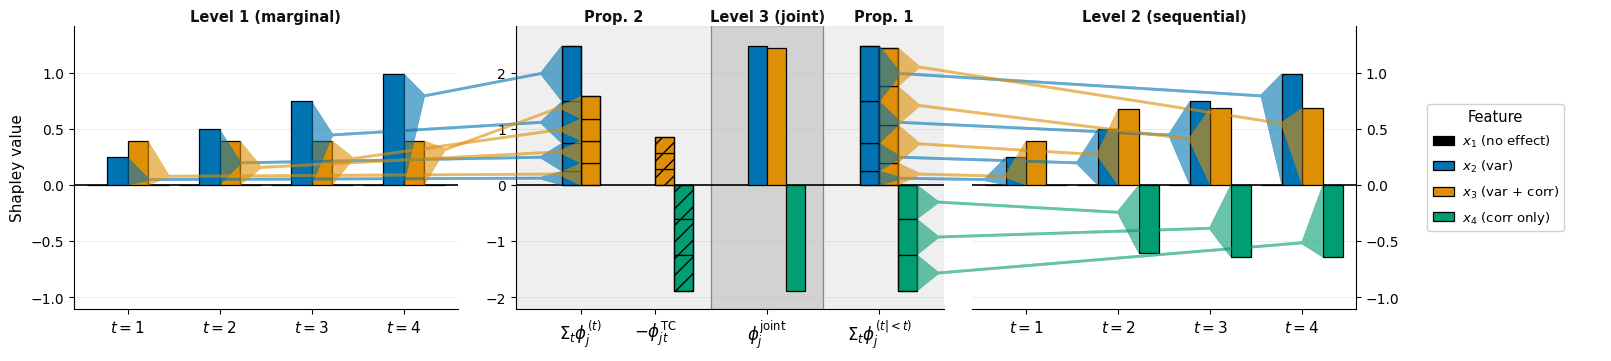

In [6]:
FEATURE_ROLES = ['mean', 'var', 'var + corr', 'corr only']
FEAT_COLORS = ["#000000", *sns.color_palette("colorblind", n_colors=3).as_hex()]
FEAT_LABELS = [
    r'$x_1$ (no effect)',
    r'$x_2$ (var)',
    r'$x_3$ (var + corr)',
    r'$x_4$ (corr only)',
]


BW  = 0.16
TS  = 0.72
OFF = BW * np.array([-(p - 1) / 2 + j for j in range(p)])
t_local = np.arange(T, dtype=float) * TS

w_side = T * TS + 0.7
fig = plt.figure(figsize=(16, 3.5), layout='constrained')
gs   = fig.add_gridspec(1, 4, width_ratios=[w_side, 4.0, w_side, 1.55], wspace=0.07)
ax_l   = fig.add_subplot(gs[0])
ax_m   = fig.add_subplot(gs[1])
ax_r   = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3]); ax_leg.axis('off')

sl1 = 0.55;  crx = sl1 + 0.63;  jx = crx + 0.95;  sl2 = jx + 0.95
x_lo_m, x_hi_m = 0.0, sl2 + 0.55
sep_B_m = (crx + jx) / 2;  sep_C_m = (jx + sl2) / 2

def draw_grouped(ax, vals, centers, labels=False):
    for j in range(p):
        kw = dict(color=FEAT_COLORS[j], zorder=3, edgecolor='black', lw=0.9)
        if labels: kw['label'] = FEAT_LABELS[j]
        ax.bar(centers + OFF[j], vals[:, j], BW, **kw)

def draw_stacked(ax, time_data, xc, hatch=None):
    for j in range(p):
        xp = xc + OFF[j];  bp, bn = 0.0, 0.0
        for t in range(T):
            v = float(time_data[t, j])
            if abs(v) < 1e-3: continue
            b = bp if v >= 0 else bn
            kw = dict(color=FEAT_COLORS[j], edgecolor='black', lw=0.9, zorder=3)
            if hatch: kw['hatch'] = hatch
            ax.bar(xp, v, BW, bottom=b, **kw)
            if v >= 0: bp += v
            else:      bn += v
        tot = float(time_data[:, j].sum())
        if abs(tot) > 1e-3:
            ax.add_patch(Rectangle((xp - BW/2, min(0., tot)), BW, abs(tot),
                fill=False, edgecolor='black', lw=0.9, zorder=4))

def draw_vec(ax, vec, xc, hatch=None):
    for j in range(p):
        v = float(vec[j])
        if abs(v) < 1e-3: continue
        kw = dict(color=FEAT_COLORS[j], edgecolor='black', lw=0.9, zorder=3)
        if hatch: kw['hatch'] = hatch
        ax.bar(xc + OFF[j], v, BW, **kw)

draw_grouped(ax_l, phi_L1, t_local, labels=True)
draw_stacked(ax_m, phi_L1, sl1)
draw_stacked(ax_m, -phi_cross_t, crx, hatch='//')
draw_vec(ax_m, phi_L3, jx)
draw_stacked(ax_m, phi_L2, sl2)
draw_grouped(ax_r, phi_L2, t_local)

def fmt_ax(ax, xlim, sections, ylabel=None, hide_left=False, hide_right=False):
    ax.set_xlim(*xlim)
    ax.axhline(0, color='black', lw=1.2, zorder=2)
    ax.grid(axis='y', lw=0.4, alpha=0.4, zorder=1)
    ax.spines['top'].set_visible(False)
    if hide_left:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)
    if hide_right:
        ax.spines['right'].set_visible(False)
    if ylabel: ax.set_ylabel(ylabel, fontsize=11)
    tr = ax.get_xaxis_transform()
    for i, (x1, x2, color, label) in enumerate(sections):
        ax.axvspan(x1, x2, color=color, alpha=0.35, zorder=0)
        if i > 0: ax.axvline(x1, color='#888', lw=0.8, zorder=1)
        ax.text((x1+x2)/2, 1.005, label, ha='center', va='bottom',
                fontsize=10.5, color='#111', transform=tr,
                fontweight='bold')

x_lo_l, x_hi_l = t_local[0] - 0.42, t_local[-1] + 0.42
fmt_ax(ax_l, (x_lo_l, x_hi_l), [(x_lo_l, x_hi_l, 'white', 'Level 1 (marginal)')],
       ylabel='Shapley value', hide_right=True)
fmt_ax(ax_m, (x_lo_m, x_hi_m),
       [(x_lo_m,  sep_B_m, 'lightgray', 'Prop. 2'),
        (sep_B_m, sep_C_m, 'gray',      'Level 3 (joint)'),
        (sep_C_m, x_hi_m,  'lightgray', 'Prop. 1')],
       hide_right=True)
fmt_ax(ax_r, (x_lo_l, x_hi_l), [(x_lo_l, x_hi_l, 'white', 'Level 2 (sequential)')],
       hide_left=True)
ax_r.spines['right'].set_visible(True)
ax_r.tick_params(right=True, labelright=True)

t_labs = [f'$t={i+1}$' for i in range(T)]
ax_l.set_xticks(t_local); ax_l.set_xticklabels(t_labs, fontsize=11)
ax_m.set_xticks([sl1, crx, jx, sl2])
ax_m.set_xticklabels([
    r'$\Sigma_t\phi^{(t)}_j$', r'$-\phi^{\rm TC}_{jt}$',
    r'$\phi^{\rm joint}_j$',   r'$\Sigma_t\phi^{(t|{<}t)}_j$',
], fontsize=12)
ax_r.set_xticks(t_local); ax_r.set_xticklabels(t_labs, fontsize=11)
for ax in (ax_l, ax_m, ax_r):
    ax.tick_params(axis='y', labelsize=10)

handles, labels_leg = ax_l.get_legend_handles_labels()
ax_leg.legend(handles, labels_leg, fontsize=9.5, ncols=1, title='Feature',
              title_fontsize=10.5, framealpha=0.9,
              loc='center left', bbox_to_anchor=(-0.05, 0.5),
              borderaxespad=0., handlelength=1.6, handletextpad=0.6,
              labelspacing=0.7)

fig.canvas.draw()
y_max = max(v for ax in [ax_l, ax_m, ax_r] for v in ax.get_ylim()) * 1.05
y_min = min(v for ax in [ax_l, ax_m, ax_r] for v in ax.get_ylim()) * 1.05
ax_m.set_ylim(y_min, y_max)
ax_l.set_ylim(y_min / 2, y_max / 2)
ax_r.set_ylim(y_min / 2, y_max / 2)
fig.canvas.draw()  # re-run constrained layout with final ylims before computing ribbon coords

# ── Ribbons ──────────────────────────────────────────────────────────────────
def stk_bounds(phi):
    segs = {}
    for j in range(p):
        pos, neg = 0.0, 0.0
        for t in range(T):
            v = float(phi[t, j])
            if v >= 0: segs[(j, t)] = (pos, pos + v); pos += v
            else:      segs[(j, t)] = (neg + v, neg);  neg += v
    return segs

def ribbon(ax_s, xs, ys_b, ys_t, ax_t, xt, yt_b, yt_t,
           color, t_idx, val, pin_src=True, pin_tgt=False,
           narrow=0.013, thin=0.007, alpha=0.6):
    def tf(ax, x, y):
        return (ax.transData + fig.transFigure.inverted()).transform((x, y))
    sx,  sy_t = tf(ax_s, xs, ys_t)
    _,   sy_b = tf(ax_s, xs, ys_b)
    tx,  ty_t = tf(ax_t, xt, yt_t)
    _,   ty_b = tf(ax_t, xt, yt_b)
    base_frac = (t_idx + 1) / (T + 1)
    frac      = base_frac if val >= 0 else 1 - base_frac
    sy_pin    = sy_b + frac * (sy_t - sy_b) if pin_src else (sy_t + sy_b) / 2
    ty_pin    = ty_b + frac * (ty_t - ty_b) if pin_tgt else (ty_t + ty_b) / 2
    pts = np.array([
        [sx,           sy_t           ],
        [sx + narrow,  sy_pin + thin/2],
        [tx - narrow,  ty_pin + thin/2],
        [tx,           ty_t           ],
        [tx,           ty_b           ],
        [tx - narrow,  ty_pin - thin/2],
        [sx + narrow,  sy_pin - thin/2],
        [sx,           sy_b           ],
    ])
    fig.add_artist(Polygon(pts, closed=True, facecolor=color,
        alpha=alpha, edgecolor=color, lw=0.3,
        transform=fig.transFigure, clip_on=False))

segs1 = stk_bounds(phi_L1)
segs2 = stk_bounds(phi_L2)
for j in range(p):
    for t in range(T):
        v1 = float(phi_L1[t, j])
        if abs(v1) > 1e-2:
            yb, yt_ = segs1[(j, t)]
            ribbon(ax_l, t_local[t] + OFF[j] + BW/2, min(0., v1), max(0., v1),
                   ax_m, sl1        + OFF[j] - BW/2, yb, yt_,
                   FEAT_COLORS[j], t_idx=t, val=v1, pin_src=True, pin_tgt=False)
        v2 = float(phi_L2[t, j])
        if abs(v2) > 1e-2:
            yb, yt_ = segs2[(j, t)]
            ribbon(ax_m, sl2        + OFF[j] + BW/2, yb, yt_,
                   ax_r, t_local[t] + OFF[j] - BW/2, min(0., v2), max(0., v2),
                   FEAT_COLORS[j], t_idx=t, val=v2, pin_src=False, pin_tgt=True)


# Save figure
fig.savefig(f'{plot_dir}/synthetic_hierarchy.pdf', bbox_inches='tight')
fig.savefig(f'{plot_dir}/synthetic_hierarchy.png', bbox_inches='tight', dpi=200)
plt.show()


In [7]:
print("✅  Done with Hierarchy calculation using Gaussian DGP")
print(f"Total runtime: {(time.time() - start_time):.2f} seconds")

✅  Done with Hierarchy calculation using Gaussian DGP
Total runtime: 2.92 seconds
